In [19]:
import os  
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')  
if gpus:  
    tf.config.experimental.set_memory_growth(gpus[0], True)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from keras.datasets import imdb
from keras import layers
import time
import keras.backend as K
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

### Zadanie 3

In [5]:
max_features = 5000
max_len = 100
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=max_features)

X_train = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=max_len)
X_test = keras.preprocessing.sequence.pad_sequences(X_test, maxlen=max_len)

models = {'RNN': keras.Sequential([
              layers.Embedding(input_dim=max_features, output_dim=32),
              layers.SimpleRNN(32),
              layers.Dropout(0.2),
              layers.Dense(1, activation='sigmoid')]),
          'LSTM': keras.Sequential([
              layers.Embedding(input_dim=max_features, output_dim=64),
              layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2),
              layers.Dropout(0.2),
              layers.Dense(1, activation='sigmoid')])
}

histories = {}
for k, v in models.items():
  v.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
  histories[k] = v.fit(X_train, y_train, epochs=5, batch_size=128, validation_split=0.2, verbose=0)

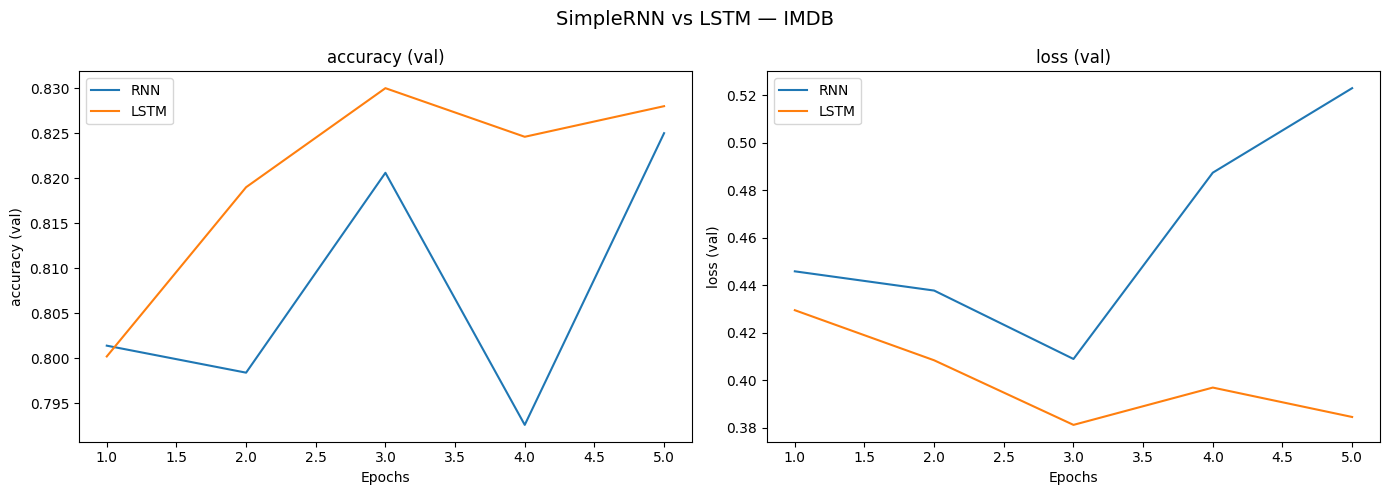

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics = [('val_accuracy', 'accuracy (val)'),
           ('val_loss', 'loss (val)')]

for ax, (metric, title) in zip(axes, metrics):
    for name, hist in histories.items():
        epochs = range(1, len(hist.history[metric]) + 1)
        ax.plot(epochs, hist.history[metric], label=name)
    ax.set_title(title)
    ax.set_xlabel('Epochs')
    ax.set_ylabel(title)
    ax.legend()

plt.suptitle('SimpleRNN vs LSTM — IMDB', fontsize=14)
plt.tight_layout()
plt.show()

### Zadanie 5

In [7]:
max_lengths = [50, 100, 200, 500]
(X_train_raw, y_train), (X_test_raw, y_test) = keras.datasets.imdb.load_data(num_words=max_features)

padded = {l: (
    keras.preprocessing.sequence.pad_sequences(X_train_raw, maxlen=l),
    keras.preprocessing.sequence.pad_sequences(X_test_raw,  maxlen=l)
) for l in max_lengths}

results = {}
for length in max_lengths:
    K.clear_session()
    X_train, X_test = padded[length]

    model = keras.Sequential([
        layers.Embedding(input_dim=max_features, output_dim=64),
        layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    start = time.time()
    model.fit(X_train, y_train, epochs=5, batch_size=128, verbose=1)
    elapsed = time.time() - start

    _, acc = model.evaluate(X_test, y_test, verbose=0)
    results[length] = {'Accuracy': round(acc, 4), 'Time (s)': round(elapsed, 1)}

pd.DataFrame(results).T

Epoch 1/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 27s 130ms/step - accuracy: 0.7383 - loss: 0.5274
Epoch 2/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 27s 137ms/step - accuracy: 0.8291 - loss: 0.3905
Epoch 3/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 28s 145ms/step - accuracy: 0.8497 - loss: 0.3561
Epoch 4/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 129ms/step - accuracy: 0.8562 - loss: 0.3369
Epoch 5/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 27s 136ms/step - accuracy: 0.8653 - loss: 0.3166
Epoch 1/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 53s 262ms/step - accuracy: 0.7567 - loss: 0.5041
Epoch 2/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 49s 252ms/step - accuracy: 0.8508 - loss: 0.3538
Epoch 3/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 50s 254ms/step - accuracy: 0.8698 - loss: 0.3216
Epoch 4/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 49s 250ms/step - accuracy: 0.8814 - loss: 0.2918
Epoch 5/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 49s 249ms/step - accuracy: 0.8894 - loss: 0.2744
Epoch 1/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 105s 528ms/step - accuracy: 0.7440 - loss: 0.5103
Epoch 2/5
196/196 ━━━━━━━━━━━━━

,Accuracy,Time (s)
50,0.8106,134.3
100,0.8417,250.3
200,0.8028,529.4
500,0.7618,1326.6


### Zadanie 10
Wygeneruj syntetyczny szereg czasowy (sinusoida + trend + szum). Wytrenuj GRU do predykcji nastepnej wartosci. Zwizualizuj predykcje.

Wymagania:
* create_sequences() z oknem 30 krokow
* GRU(32) + Dense(1)
* Wykres: rzeczywiste vs predykcje
* MSE, MAE


In [26]:
np.random.seed(42)
t = np.arange(0, 200, 0.1)
data = np.sin(t) * 10 + np.random.randn(len(t)) * 1.5 + t * 0.05
window = 30

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data.reshape(-1,1)).flatten()

X = []
y = []
for i in range(len(data_scaled) - window):
    X.append(data_scaled[i : i + window])
    y.append(data_scaled[i + window])
X, y = np.array(X), np.array(y)
X = X.reshape(X.shape[0], X.shape[1],1)

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = keras.Sequential([
    layers.Input(shape=(window,1)),
    layers.GRU(32, reset_after=False),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(X_train, y_train, epochs=5, batch_size=128, verbose=0)
y_pred_scaled = model.predict(X_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


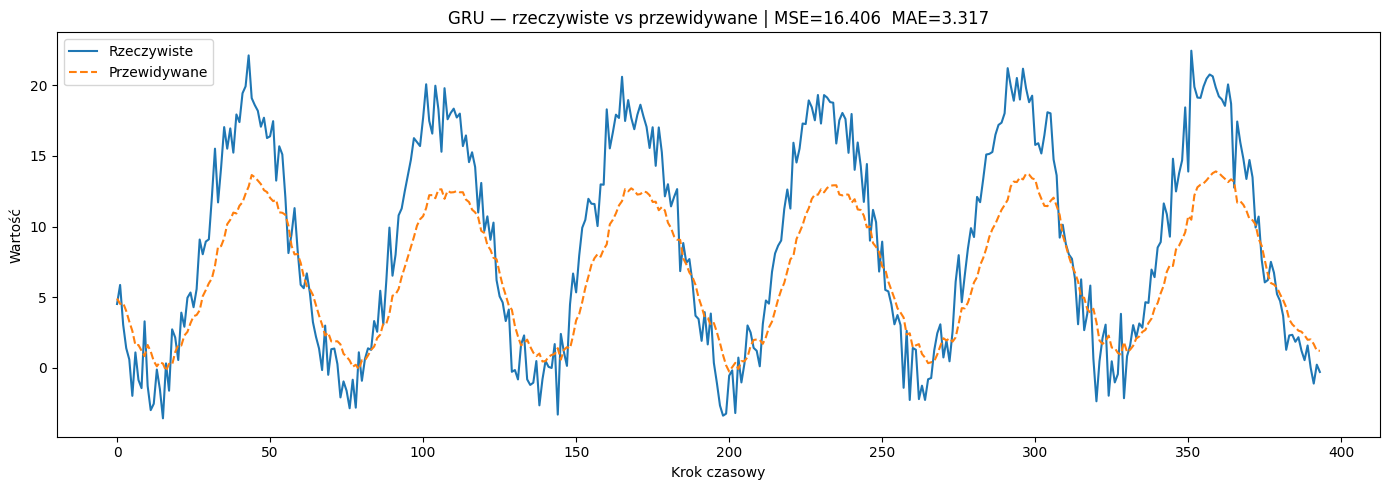

In [27]:
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_real = scaler.inverse_transform(y_pred_scaled).flatten()

mse = mean_squared_error(y_test_real, y_pred_real)
mae = mean_absolute_error(y_test_real, y_pred_real)

plt.figure(figsize=(14, 5))
plt.plot(y_test_real, label='Rzeczywiste', linewidth=1.5)
plt.plot(y_pred_real, label='Przewidywane', linestyle='--', linewidth=1.5)
plt.title(f'GRU — rzeczywiste vs przewidywane | MSE={mse:.3f}  MAE={mae:.3f}')
plt.xlabel('Krok czasowy')
plt.ylabel('Wartość')
plt.legend()
plt.tight_layout()
plt.show()